In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from scipy.signal import find_peaks

# Orthogonal Polarizer axes - analysis 

In [87]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_ortogonal.csv')
I_med = medicion['voltaje']-0.00194
theta = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.003218,0
1,0.006484,10
2,0.011864,20
3,0.014984,30
4,0.014939,40


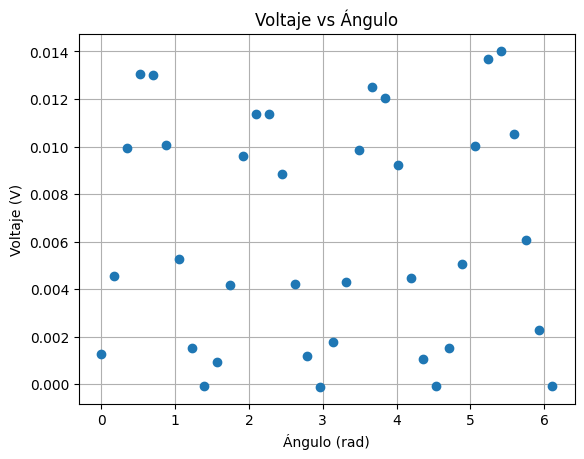

In [88]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta, I_med, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (28,) and (20,)

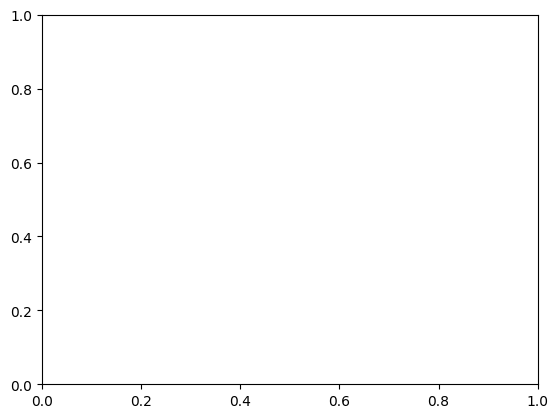

In [90]:
I_med=I_med[8:]
plt.plot(theta[8:], I_med, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

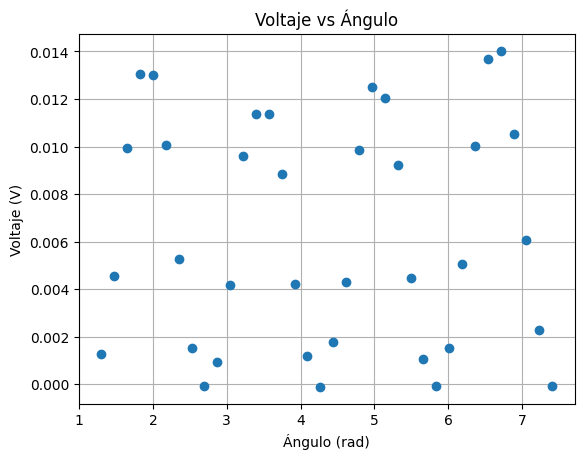

In [77]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta, I_med, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [78]:
# --- estimate S0 --- and normalize voltaje
# --- Identify peaks in the voltage data to select the mean as the normalization factor ---
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = theta[peaks_volt]
norm_number = medicion['voltaje'][peaks_volt].mean()
display(f'Normalization number: {norm_number}')

I_med = I_med / norm_number


'Normalization number: 0.0146752'

In [79]:
S0 = np.max(I_med)
print(f'S0: {S0}')

S0: 0.9554622764936763


S0 = 0.9554622764936763
S1 = 0.12067860483598827
S2 = 0.954352774034373
S3 = -0.3572924945394372

Deltas:
d1 = 3.174784330229061
d2 = 2.8083834082461814
d3 = 3.999735168608757
d4 = 2.489544179317382

DOP = 1.073996335799324


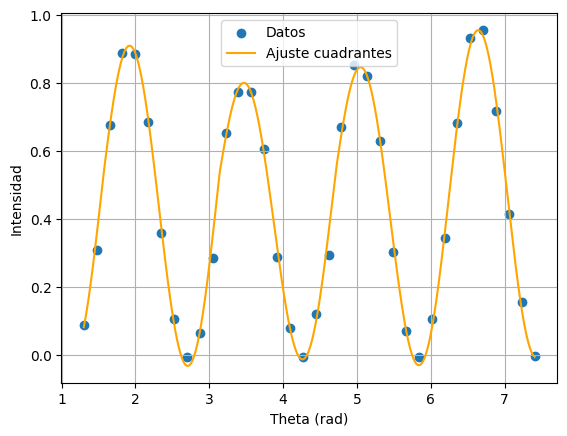

In [81]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med

# --- initial conditions ---
initial_guess = [
    0.1*S0,  # S1
    0.1*S0,  # S2
    0.1*S0,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0, -S0, -S0,
    0, 0, 0, 0
]

upper_bounds = [
    S0, S0, S0,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0 =", S0)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

In [83]:
#we can also plot the points on the Poincare sphere

def plot_poincare_sphere(ax, s_fit):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    ax.scatter(s_fit[0], s_fit[1], s_fit[2], s=90, label="Fitted point")
    ax.plot([0, s_fit[0]], [0, s_fit[1]], [0, s_fit[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()



[ 0.12630389  0.99883878 -0.37394725]


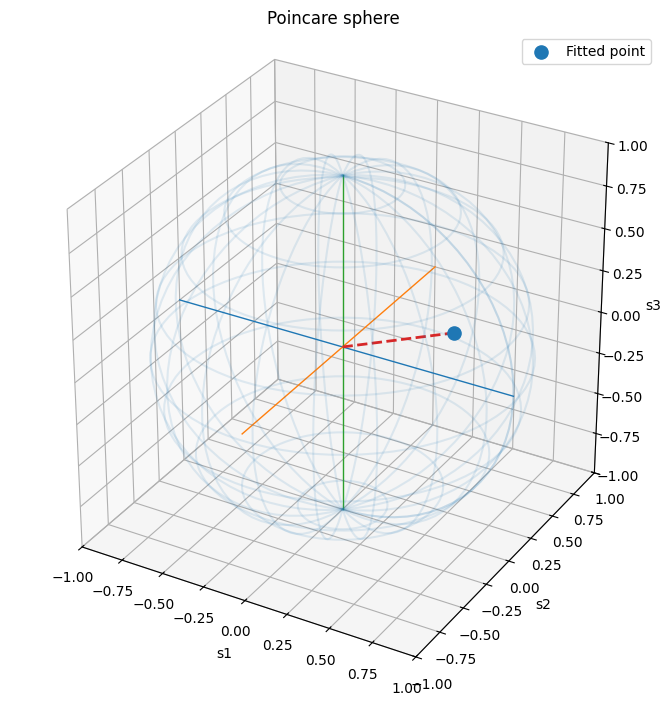

In [85]:
fig_new = plt.figure(figsize=(7, 7))
s_fit=np.array([S1_fit, S2_fit, S3_fit]/S0  )
print(s_fit)
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new,  s_fit)
plt.tight_layout()
plt.show()

# Parallel polarizer axes - Analysis

In [63]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_paralelo.csv')
I_med = medicion['voltaje']-0.00194
theta = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.069970,0
1,0.062231,10
2,0.053607,20
3,0.039862,30
4,0.034066,40


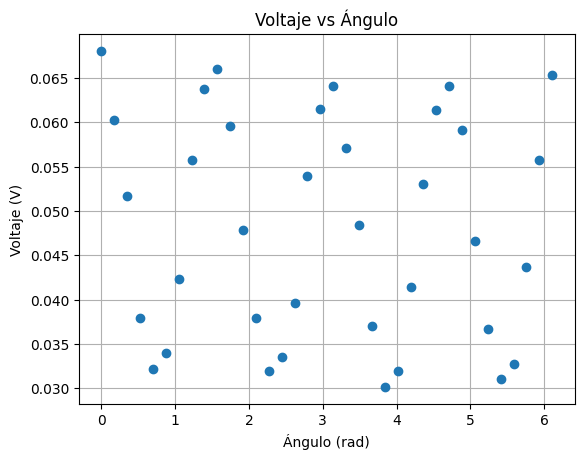

In [64]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta, I_med, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [65]:
# --- estimate S0 --- and normalize voltaje
# --- Identify peaks in the voltage data to select the mean as the normalization factor ---
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = theta[peaks_volt]
norm_number = medicion['voltaje'][peaks_volt].mean()
display(f'Normalization number: {norm_number}')

I_med = I_med / norm_number


'Normalization number: 0.0666576'

In [66]:
S0 = np.max(I_med)
print(f'S0: {S0}')

S0: 1.0205827992606997


S0 = 1.0205827992606997
S1 = 0.9394488260862993
S2 = -0.15626958201682445
S3 = 0.008996700365207439

Deltas:
d1 = 1.6074862183296472
d2 = 1.6772450283217624
d3 = 1.6863682435570286
d4 = 1.6745540834331292

DOP = 0.9331920124917766


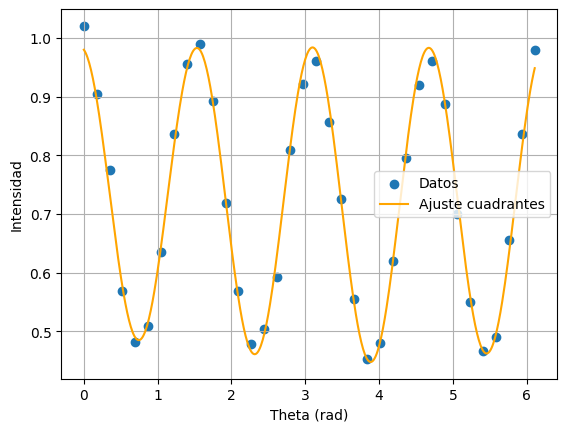

In [67]:
# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med

# --- initial conditions ---
initial_guess = [
    0.1*S0,  # S1
    0.1*S0,  # S2
    0.1*S0,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0, -S0, -S0,
    0, 0, 0, 0
]

upper_bounds = [
    S0, S0, S0,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0 =", S0)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

[ 0.92050231 -0.15311799  0.00881526]


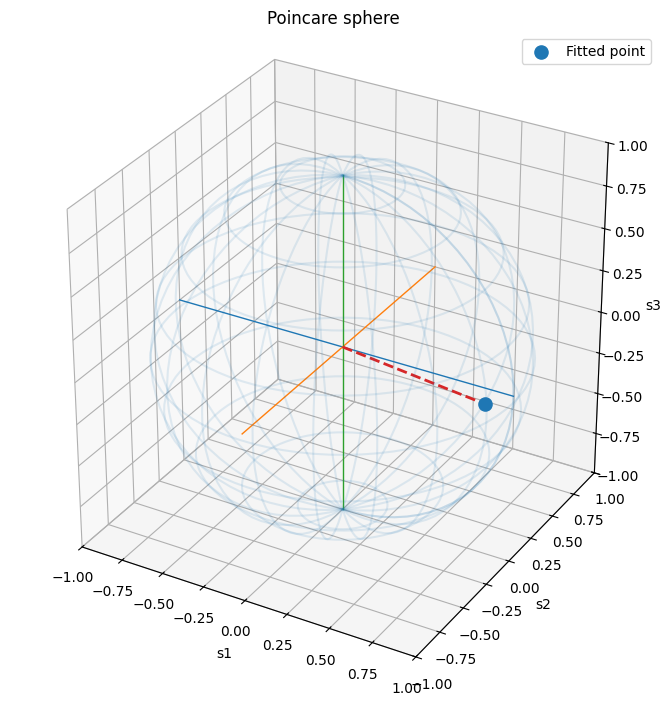

In [68]:
fig_new = plt.figure(figsize=(7, 7))
s_fit=np.array([S1_fit, S2_fit, S3_fit]/S0  )
print(s_fit)
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new,  s_fit)
plt.tight_layout()
plt.show()

# Comparison of both polarizations 

In [69]:
def plot_poincare_sphere(ax, s_points):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- plot de múltiples puntos ---
    for i, s in enumerate(s_points):
        ax.scatter(s[0], s[1], s[2], s=90, label=f"Point {i+1}")
        ax.plot([0, s[0]], [0, s[1]], [0, s[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [70]:
s1=np.array([-0.84211379 , 0.71355784 , 0.23909739] )
s2=np.array([ 0.92050231, -0.15311799,  0.00881526] )

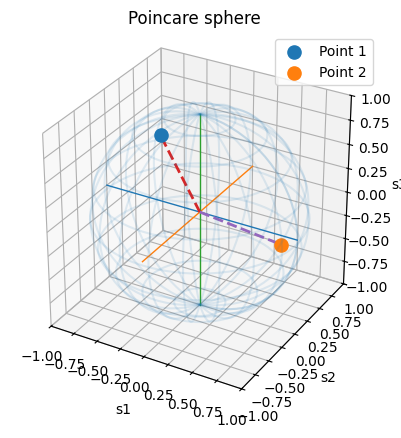

In [71]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_poincare_sphere(ax, [s1, s2])

plt.show()